# L2 Space Similarity Search

In [5]:
import chromadb
from PIL import Image
import matplotlib.pyplot as plt

Load in the chroma database, along with the Validation and Dataset 3, as both have been already filtered through cosine similarity.

In [6]:
# Connect to ChromaDB
client = chromadb.PersistentClient(path="../data/chroma_db")
client.list_collections()

[Collection(name=dataset3_without_augmentation),
 Collection(name=dataset3_images),
 Collection(name=val_clean_01),
 Collection(name=d3_clean_01),
 Collection(name=validation_images),
 Collection(name=dataset2_images)]

In [7]:
# Load original validation images
val = client.get_collection("val_clean_01")
val.peek(limit=1)

{'ids': ['0'],
 'embeddings': array([[0.01869522, 0.        , 0.05107115, ..., 0.06092875, 0.1196442 ,
         0.        ]], shape=(1, 2048)),
 'documents': ['..\\data\\valid\\images\\imagess_1000.jpg'],
 'uris': None,
 'included': ['metadatas', 'documents', 'embeddings'],
 'data': None,
 'metadatas': [None]}

In [8]:
d3 = client.get_collection("d3_clean_01")
d3.peek(limit=1)

{'ids': ['0'],
 'embeddings': array([[0.        , 0.        , 0.06523973, ..., 0.0472009 , 0.        ,
         0.        ]], shape=(1, 2048)),
 'documents': ['..\\data\\images_dataset_3\\bangladeshi-biker-7444388_640.jpg'],
 'uris': None,
 'included': ['metadatas', 'documents', 'embeddings'],
 'data': None,
 'metadatas': [None]}

## Compare Different Collections

First, we need a function that can take two collections, and search every image from the first collection against all the images in the second collection.

In [ ]:
def compare_collections(target_collection, query_collection=None, k=1):
    """
    Compare two collections of images.
    :param target_collection: ChromaDB collection to compare inividual images
    :param query_collection: ChromaDB collection to search entire collection
    :param k: Number of results to return
    :return: List of dictionaries with target path and list of results dictionaries with result path and distance
    """
    # If no second collection is provided, compare target collection to itself
    if query_collection is None:
        query_collection = target_collection
    target_results = []
    for idx in range(target_collection.count()):
        target_result = target_collection.get(ids=[str(idx)], include=['embeddings', 'documents'])
        target_embedding = target_result['embeddings'][0]
        target_path = target_result['documents'][0]

        results = query_collection.query(
            query_embeddings=[target_embedding],
            n_results=k
        )

        result_entry_list = []
        for idx, result_path in enumerate(results['documents'][0]):
            # Check if result is the target image
            if result_path == target_path:
                continue
            else:
                result_entry = {
                    'result_path': result_path,
                    'result_distance': results['distances'][0][idx]
                }
                result_entry_list.append(result_entry)

        entry = {
            'target_path': target_path,
            'results': result_entry_list
        }

        target_results.append(entry)

    return target_results


In [ ]:
def sort_results(target_results):
    """
    Sort results by first distance in results list
    :param target_results: List of dictionaries with target path and list of results dictionaries with result path and distance
    :return: Sorted list of dictionaries with target path and list of results dictionaries with result path and distance
    """
    # Sort the results by the first distance
    sorted_results = sorted(target_results, key=lambda x: x['results'][0]['result_distance'])
    return sorted_results

In [ ]:
def multi_line_title(title):
    """
    Split title into multiple lines if it's too long, used for display
    :param title: Title of image
    :return: Multi-line title
    """
    if len(title) > 25:
        new_title = f"[{title[:25]}\n{title[25:]}]"
    else:
        new_title = title
    return new_title

In [ ]:
def display_similar_images(target_path, similar_results):
    """
    Display similar images in a figure
    :param target_path: Path to target image
    :param similar_results: List of dictionaries with result path and distance
    :return: None
    """
    n_similar = len(similar_results)
    n_cols = n_similar + 1  # +1 for searched image
    fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4))
    
    # Handle single subplot case
    if n_cols == 2:
        axes = [axes[0], axes[1]]
    
    # Display validation image
    target_img = Image.open(target_path)
    target_title = multi_line_title(target_path.split('\\')[-1])
    axes[0].imshow(target_img)
    axes[0].set_title(f"Searching with Image:\n{target_title}", fontweight='bold')
    axes[0].axis('off')
    
    # Display similar images
    for idx, result in enumerate(similar_results):
        result_path = result['result_path']
        distance = result['result_distance']
        
        result_img = Image.open(result_path)
        result_title = multi_line_title(result_path.split('\\')[-1])
        axes[idx + 1].imshow(result_img)
        axes[idx + 1].set_title(f"DISTANCE: {distance:.2f}\n{result_title}")
        axes[idx + 1].axis('off')
    
    plt.tight_layout()
    plt.show()

In [ ]:
def get_tenth_percentile(sorted_results):
    """
    Get 10th percentile of distances
    :param sorted_results: Sorted list of dictionaries with target path and list of results dictionaries with result path and distance
    :return: 10th percentile of distances
    """
    # Use the first result distance of every result
    percentile_10 = (sorted_results[-1]['results'][0]['result_distance'] - sorted_results[0]['results'][0]['result_distance']) * 0.1
    return percentile_10

In [80]:
def get_similar_images(target_collection, query_collection, k=1, min_distance=0, max_distance=None):
    target_results = compare_collections(target_collection, query_collection, k=k)
    sorted_results = sort_results(target_results)
    if max_distance is None:
        max_distance = get_tenth_percentile(sorted_results)
        print(f"Max distance - using 10th percentile: {max_distance}")

    similar_results = []
    for result in sorted_results:
        if min_distance <= result['results'][0]['result_distance'] <= max_distance:
            similar_results.append(result)
            display_similar_images(result['target_path'], result['results'])
    
    print("=" * 20)
    print(f"Total similar images: {len(similar_results)}")

Checking for data leakage from the validation dataset versus dataset 3. I'm using max distance of 20, as from what I saw in testing, this a a decent value that can find even cropped images that are the same.

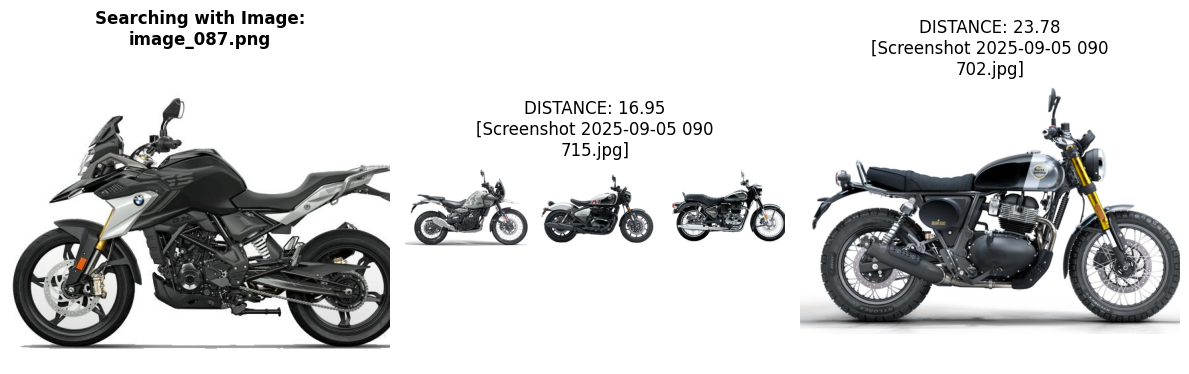

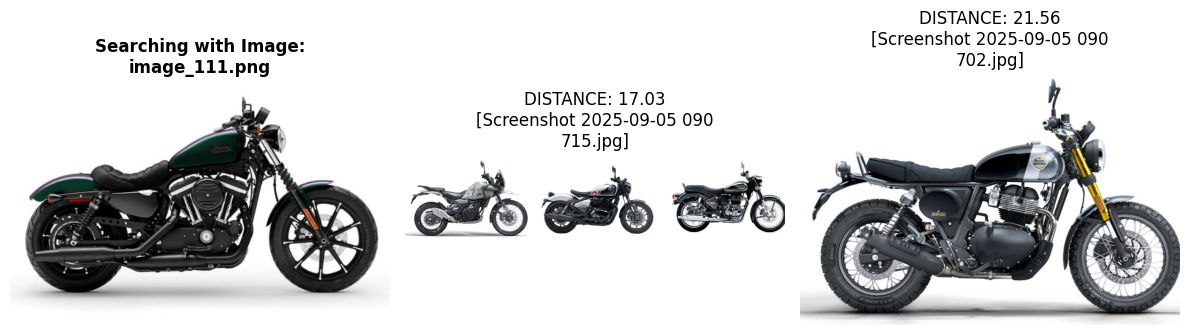

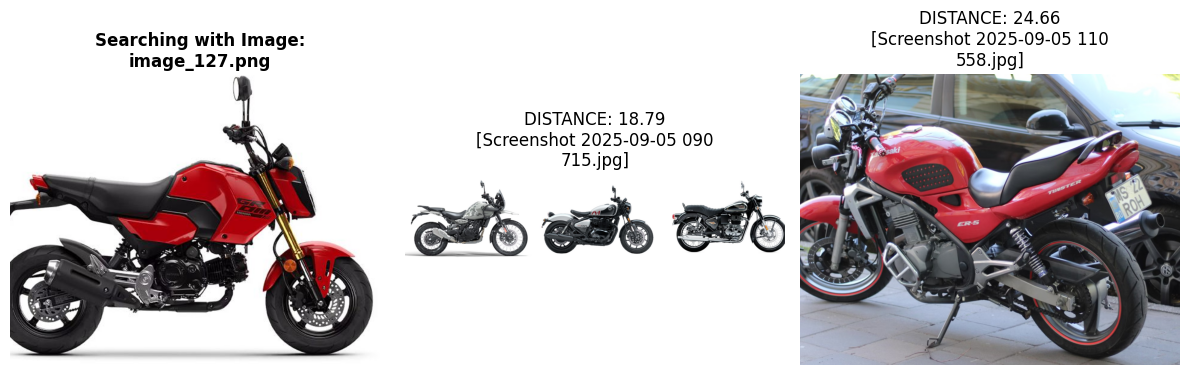

Total similar images: 3


In [84]:
get_similar_images(val, d3, k=2, max_distance=20)

Looks like there really isn't any data leakage from validation to dataset 3.

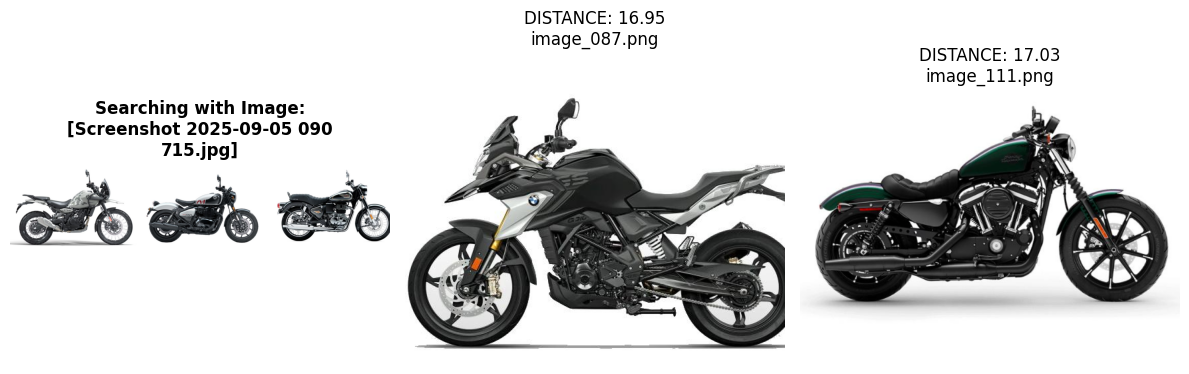

Total similar images: 1


In [104]:
get_similar_images(d3, val, k=2, max_distance=20)

Searching the other way also does not show any duplicates.

## Analyze One Dataset for Similarity

We need some way to find similar images within a dataset, so we can find duplicates but also find the same image but augmented.

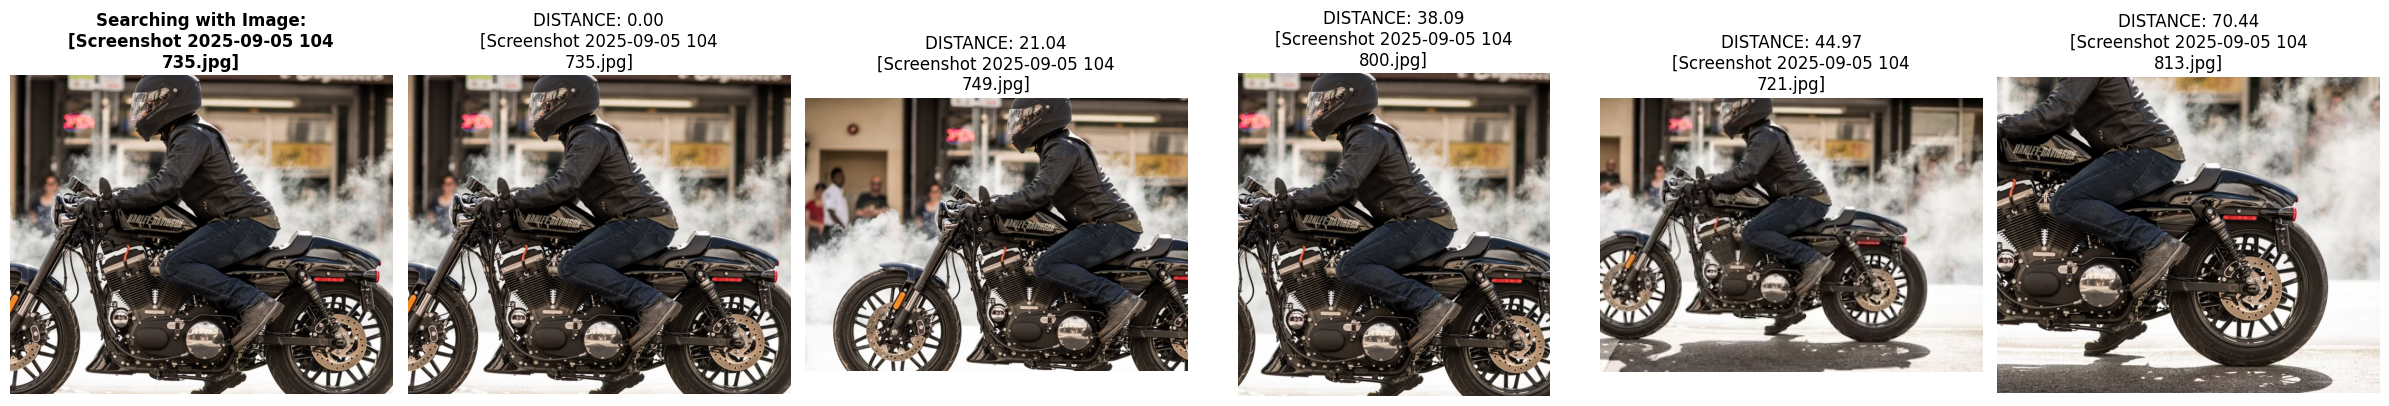

In [ ]:
# Cherry pick a test example to demonstrate
similarity_test = d3.get(
    where_document={
        "$contains": "Screenshot 2025-09-05 104735"
    },
    include=['documents', 'embeddings']
)

# Search the test example against the same dataset
test_results = d3.query(
    query_embeddings=similarity_test['embeddings'],
    n_results=5
)

# Pull out the metadata for display
target_path = similarity_test['documents'][0]
similar_results = []
for idx, result_path in enumerate(test_results['documents'][0]):
    entry = {
        'result_path': result_path,
        'result_distance': test_results['distances'][0][idx]
    }
    similar_results.append(entry)
display_similar_images(target_path, similar_results)

As we can see from the example above, all of these images have the same base image, they just have various cropping applied. There's not a perfect distance that tells us exactly if the base image is the same, but from testing, a distance of 20 is a good bet.

## Duplicates

First, we should check for duplicates. As seen in the example above, if the distance is 0, it's an exact copy. In the example above, it's literally the exact same file, so we will need to make sure to filter out the target image distance to itself.

In [ ]:
def get_collection_duplicates(target_collection, max_distance=1):
    # k=2 because k=1 is the target image
    duplicates = compare_collections(target_collection, k=2)
    sorted_duplicates = sort_results(duplicates)
    found_duplicates = []
    for result in sorted_duplicates:
        target_path = result['target_path']
        result_path = result['results'][0]['result_path']
        result_distance = result['results'][0]['result_distance']
        # if distance is less than 1, it's probably a duplicate
        if result_distance <= max_distance and result_path not in found_duplicates:
            # put the target in the list as it has a duplicate and we don't need to check it again
            found_duplicates.append(target_path)
            display_similar_images(target_path, result['results'])

    return found_duplicates

### Dataset 3 Duplicates

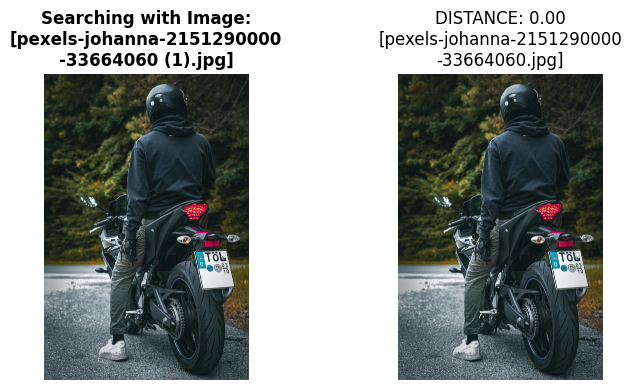

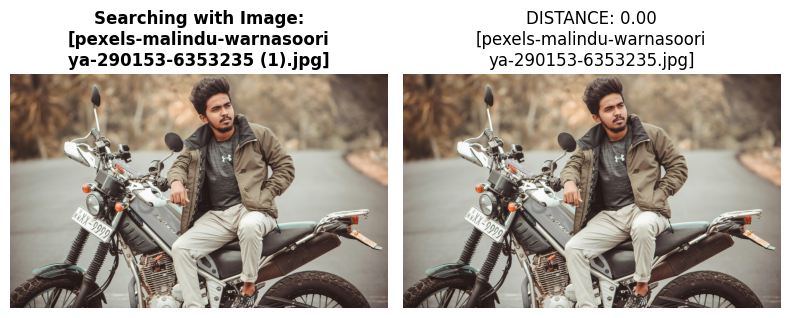

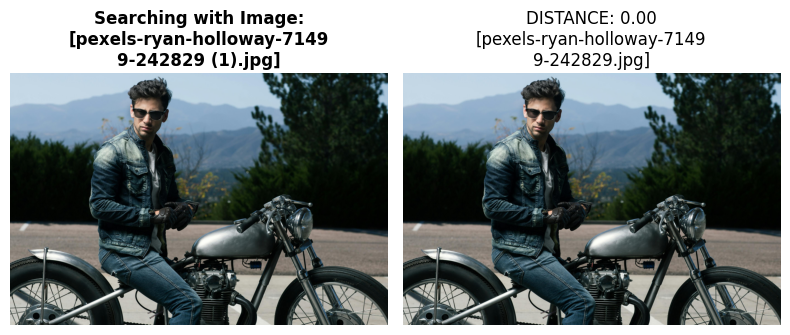

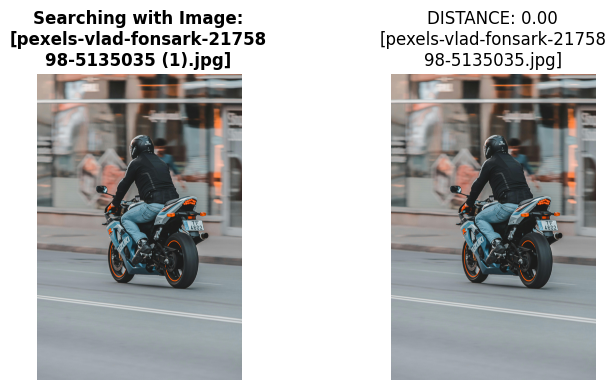

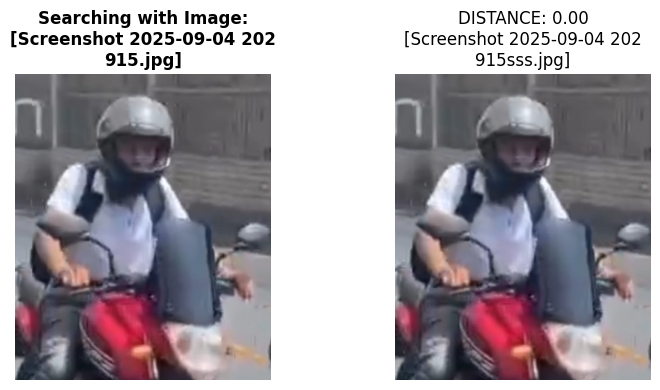

In [97]:
d3_dups = get_collection_duplicates(d3)

In [98]:
d3_dups

['..\\data\\images_dataset_3\\pexels-johanna-2151290000-33664060 (1).jpg',
 '..\\data\\images_dataset_3\\pexels-malindu-warnasooriya-290153-6353235 (1).jpg',
 '..\\data\\images_dataset_3\\pexels-ryan-holloway-71499-242829 (1).jpg',
 '..\\data\\images_dataset_3\\pexels-vlad-fonsark-2175898-5135035 (1).jpg',
 '..\\data\\images_dataset_3\\Screenshot 2025-09-04 202915.jpg']

### Val Duplicates

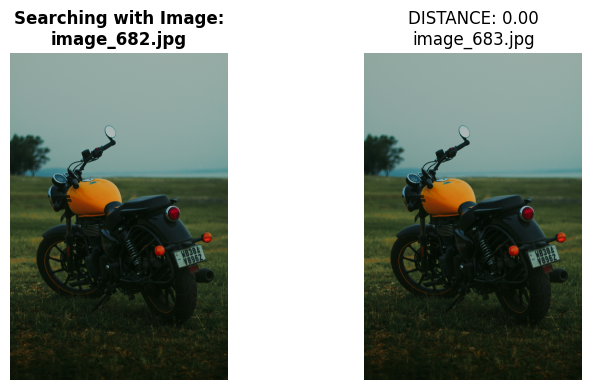

In [100]:
val_dups = get_collection_duplicates(val)

In [101]:
val_dups

['..\\data\\valid\\images\\image_682.jpg']